# Cell Type Mapping Benchmark: Sparsity Analysis

This notebook generates a comprehensive benchmark dataset for evaluating cell type mapping algorithms under varying sparsity conditions. 

## Benchmark Design

**Focus**: How do different sparsity levels affect cell type assignment accuracy?

**Dataset specifications**:
- **10 FOVs** with diverse tissue architectures
- **Controllable sparsity** via gene sensitivity and detection efficiency
- **Variable difficulty** through cell size, spatial structure, and expression overlap
- **Technical noise** including background and dropouts
- **No batch effects** (controlled comparison)

**Tissue diversity**:
1. Glandular tissue (crypts)
2. Layered cortex
3. Vascular network
4. Lymphoid follicles
5. Muscle fibers
6. Tumor microenvironment
7. Fibrillar stroma
8. Complex glandular units
9. Branching structures
10. Mixed tissue interface

---

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Ellipse
from matplotlib.collections import PatchCollection
import seaborn as sns
from pathlib import Path
import json
from datetime import datetime

from pointillsim import (
    TissueCellTypes,
    CellTypesProperties,
    HybISS_Setup,
    FOVDistribution,
    FrameWideElement,
    RandomCellTypeRule,
    MixOfNCellTypesRule,
    SingleTypeRule,
    ProbabilityNodeFieldRule,
)

from pointillsim.elements import (
    VacuolatedStructure,
    LinearLumenStructure,
    LayeredElement,
    BranchingStructure,
    FibrillarStructure,
    ClusterElement,
    GlandularUnit,
    InterfaceElement,
)

from pointillsim.rules.composite import LayerRule, GradientRule, CompositeRule, DistanceBasedRule
from pointillsim.effects import Lateral2DAdmixture

# Set style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.facecolor'] = 'white'

# Create output directories
Path('benchmarks/data').mkdir(parents=True, exist_ok=True)
Path('benchmarks/figures').mkdir(parents=True, exist_ok=True)
Path('benchmarks/results').mkdir(parents=True, exist_ok=True)

print("✓ Imports and setup complete")
print(f"Benchmark run: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

✓ Imports and setup complete
Benchmark run: 2026-01-28 16:30:43


## 1. Benchmark Configuration

Define controllable parameters for sparsity and difficulty.

In [2]:
# Benchmark configuration
BENCHMARK_CONFIG = {
    'n_fovs': 10,
    'frame_size': 800,
    'n_cell_types': 8,
    'n_genes': 100,
    
    # Sparsity control (key parameter)
    'sparsity_levels': {
        'very_low': {'gene_sensitivity': 1.2, 'expected_level': 20.0},   # Dense, high counts
        'low': {'gene_sensitivity': 1.0, 'expected_level': 15.0},        # Moderate-high
        'medium': {'gene_sensitivity': 0.8, 'expected_level': 12.0},     # Typical
        'high': {'gene_sensitivity': 0.5, 'expected_level': 8.0},        # Sparse
        'very_high': {'gene_sensitivity': 0.3, 'expected_level': 5.0},   # Very sparse
    },
    
    # Difficulty control
    'difficulty_levels': {
        'easy': {
            'expression_concentration': 0.9,  # Highly distinct types
            'cell_size_variation': 1.2,       # Low variation
            'spatial_mixing': 0.1,            # Well-separated
        },
        'medium': {
            'expression_concentration': 0.7,  # Moderate distinctness
            'cell_size_variation': 1.8,       # Moderate variation
            'spatial_mixing': 0.3,            # Some mixing
        },
        'hard': {
            'expression_concentration': 0.5,  # Similar types
            'cell_size_variation': 2.5,       # High variation
            'spatial_mixing': 0.5,            # High mixing
        },
    },
    
    # Technical noise
    'noise_config': {
        'background_rate': 0.02,   # 2% background dots
        'dropout_rate': 0.05,      # 5% dropout
        'position_noise': 1.5,     # Cell position noise (pixels)
    },
    
    # Cell properties variation
    'cell_sizes': [10, 12, 14, 16, 18, 14, 12, 15],  # Mean sizes per type
    'anisotropy': [0.8, 0.85, 0.9, 0.75, 0.6, 0.85, 0.9, 0.8],
}

# Assign sparsity and difficulty to each FOV
FOV_ASSIGNMENTS = [
    {'name': 'Glandular_Crypts', 'sparsity': 'medium', 'difficulty': 'easy'},
    {'name': 'Cortical_Layers', 'sparsity': 'low', 'difficulty': 'medium'},
    {'name': 'Vascular_Network', 'sparsity': 'high', 'difficulty': 'easy'},
    {'name': 'Lymphoid_Follicles', 'sparsity': 'medium', 'difficulty': 'medium'},
    {'name': 'Muscle_Fibers', 'sparsity': 'low', 'difficulty': 'hard'},
    {'name': 'Tumor_Microenv', 'sparsity': 'very_high', 'difficulty': 'hard'},
    {'name': 'Fibrillar_Stroma', 'sparsity': 'high', 'difficulty': 'medium'},
    {'name': 'Glandular_Units', 'sparsity': 'medium', 'difficulty': 'medium'},
    {'name': 'Branching_Ducts', 'sparsity': 'very_low', 'difficulty': 'easy'},
    {'name': 'Tissue_Interface', 'sparsity': 'high', 'difficulty': 'hard'},
]

print("Benchmark Configuration:")
print(f"  FOVs: {BENCHMARK_CONFIG['n_fovs']}")
print(f"  Frame size: {BENCHMARK_CONFIG['frame_size']}px")
print(f"  Cell types: {BENCHMARK_CONFIG['n_cell_types']}")
print(f"  Genes: {BENCHMARK_CONFIG['n_genes']}")
print(f"\nSparsity levels: {list(BENCHMARK_CONFIG['sparsity_levels'].keys())}")
print(f"Difficulty levels: {list(BENCHMARK_CONFIG['difficulty_levels'].keys())}")
print(f"\nFOV assignments:")
for i, fov in enumerate(FOV_ASSIGNMENTS, 1):
    print(f"  {i}. {fov['name']:20s} - Sparsity: {fov['sparsity']:10s}, Difficulty: {fov['difficulty']}")

Benchmark Configuration:
  FOVs: 10
  Frame size: 800px
  Cell types: 8
  Genes: 100

Sparsity levels: ['very_low', 'low', 'medium', 'high', 'very_high']
Difficulty levels: ['easy', 'medium', 'hard']

FOV assignments:
  1. Glandular_Crypts     - Sparsity: medium    , Difficulty: easy
  2. Cortical_Layers      - Sparsity: low       , Difficulty: medium
  3. Vascular_Network     - Sparsity: high      , Difficulty: easy
  4. Lymphoid_Follicles   - Sparsity: medium    , Difficulty: medium
  5. Muscle_Fibers        - Sparsity: low       , Difficulty: hard
  6. Tumor_Microenv       - Sparsity: very_high , Difficulty: hard
  7. Fibrillar_Stroma     - Sparsity: high      , Difficulty: medium
  8. Glandular_Units      - Sparsity: medium    , Difficulty: medium
  9. Branching_Ducts      - Sparsity: very_low  , Difficulty: easy
  10. Tissue_Interface     - Sparsity: high      , Difficulty: hard


## 2. Generate Tissue Expression Profiles

Create shared expression matrix with controllable cell type distinctness.

✓ Generated expression matrix: (100, 8)
  Cell types: Epithelial, Stromal, Endothelial, Immune_T, Immune_B, Myocyte, Fibroblast, Neural
  Mean expression per type: [0.13 0.13 0.14 0.12 0.13 0.12 0.13 0.12]


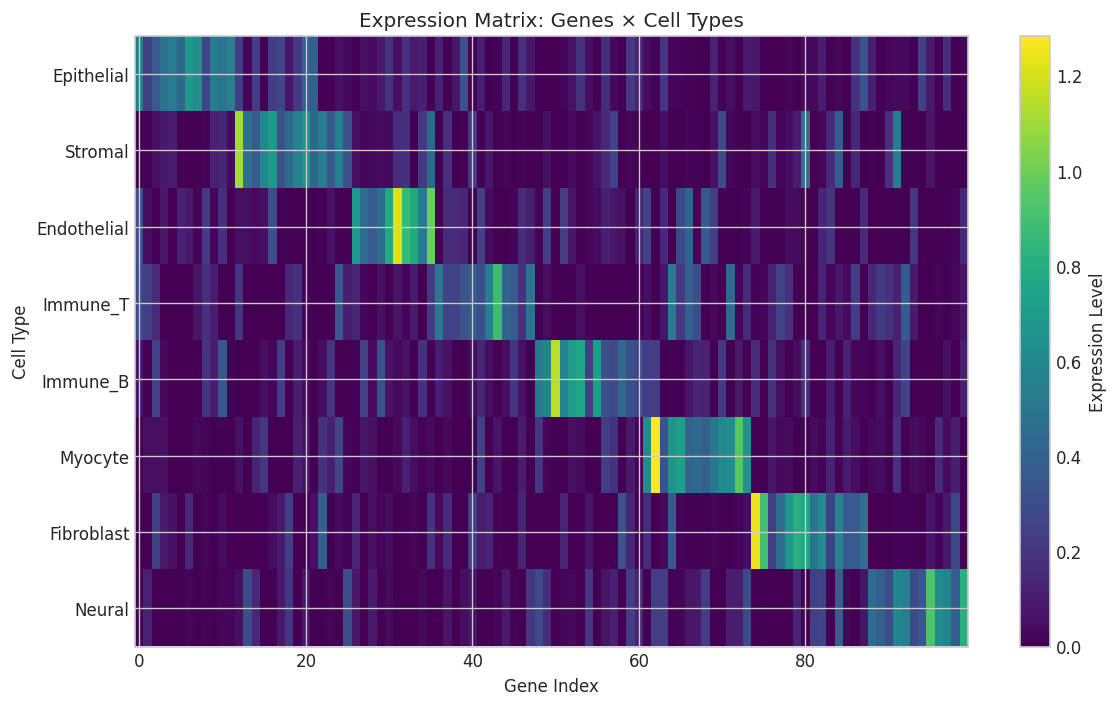


✓ Expression matrix visualization saved


In [3]:
# Generate base tissue with medium difficulty
np.random.seed(42)
tissue = TissueCellTypes()
tissue.generate_types_and_markers(
    n_genes=BENCHMARK_CONFIG['n_genes'],
    n_cell_types=BENCHMARK_CONFIG['n_cell_types'],
    expected_level=12.0,  # Will be adjusted per FOV
    concentration=0.7,    # Medium distinctness
)

# Assign cell type names
tissue._cell_type_names = [
    'Epithelial', 'Stromal', 'Endothelial', 'Immune_T', 
    'Immune_B', 'Myocyte', 'Fibroblast', 'Neural'
]

print(f"✓ Generated expression matrix: {tissue.gene_expression_by_type.shape}")
print(f"  Cell types: {', '.join(tissue._cell_type_names)}")
print(f"  Mean expression per type: {tissue.gene_expression_by_type.mean(axis=0).round(2)}")

# Visualize expression matrix
fig, ax = plt.subplots(figsize=(10, 6))
im = ax.imshow(tissue.gene_expression_by_type.T, aspect='auto', cmap='viridis', vmin=0)
ax.set_xlabel('Gene Index')
ax.set_ylabel('Cell Type')
ax.set_yticks(range(BENCHMARK_CONFIG['n_cell_types']))
ax.set_yticklabels(tissue._cell_type_names)
ax.set_title('Expression Matrix: Genes × Cell Types')
plt.colorbar(im, ax=ax, label='Expression Level')
plt.tight_layout()
plt.savefig('benchmarks/figures/expression_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Expression matrix visualization saved")

## 3. Define FOV Generators

Create diverse tissue architectures using different histological elements.

In [4]:
def create_fov_generators(frame_size, n_cell_types):
    """Create generator functions for each FOV type."""
    
    generators = {}
    
    # 1. Glandular Crypts
    def glandular_crypts():
        return FOVDistribution(
            frame_size=frame_size,
            background_element=lambda: FrameWideElement(
                frame_size=frame_size,
                tipical_cell_spacing=20,
                rules=MixOfNCellTypesRule(n_cell_types, list_N=[1, 6], proportions=[0.7, 0.3])
            ),
            other_elements=[
                lambda: VacuolatedStructure(
                    frame_size=frame_size,
                    scale=np.random.uniform(60, 90),
                    hole_scale_factor=0.5,
                    rules=LayerRule(
                        n_cell_types=n_cell_types,
                        layer_types=[0, 1],
                        layer_boundaries=[0.6],
                        transition_width=10
                    )
                )
            ],
            elements_frequency=[1.0],
            attempts_at_elements=12
        )
    
    # 2. Cortical Layers
    def cortical_layers():
        layer_rules = [
            MixOfNCellTypesRule(n_cell_types, list_N=[7, 6], proportions=[0.8, 0.2]),  # L1
            MixOfNCellTypesRule(n_cell_types, list_N=[7], proportions=[1.0]),          # L2/3
            MixOfNCellTypesRule(n_cell_types, list_N=[7, 3], proportions=[0.7, 0.3]), # L4
            MixOfNCellTypesRule(n_cell_types, list_N=[7], proportions=[1.0]),          # L5
            MixOfNCellTypesRule(n_cell_types, list_N=[6, 7], proportions=[0.6, 0.4]), # L6
        ]
        return FOVDistribution(
            frame_size=frame_size,
            background_element=lambda: LayeredElement(
                frame_size=frame_size,
                layer_boundaries=[120, 260, 440, 600],
                layer_rules=layer_rules,
                orientation='horizontal',
                tipical_cell_spacing=15
            )
        )
    
    # 3. Vascular Network
    def vascular_network():
        return FOVDistribution(
            frame_size=frame_size,
            background_element=lambda: FrameWideElement(
                frame_size=frame_size,
                tipical_cell_spacing=18,
                rules=MixOfNCellTypesRule(n_cell_types, list_N=[1, 6], proportions=[0.7, 0.3])
            ),
            other_elements=[
                lambda: LinearLumenStructure(
                    frame_size=frame_size,
                    fixed_start=np.array([np.random.uniform(50, 750), np.random.uniform(50, 750)]),
                    fixed_angle=np.random.uniform(0, 2*np.pi),
                    length=np.random.uniform(200, 400),
                    outer_radius=np.random.uniform(12, 20),
                    wall_thickness=6,
                    curvature=0.1,
                    tipical_cell_spacing=10,
                    rules=SingleTypeRule(n_cell_types, 2)
                )
            ],
            elements_frequency=[1.0],
            attempts_at_elements=8
        )
    
    # 4. Lymphoid Follicles
    def lymphoid_follicles():
        return FOVDistribution(
            frame_size=frame_size,
            background_element=lambda: FrameWideElement(
                frame_size=frame_size,
                tipical_cell_spacing=15,
                rules=MixOfNCellTypesRule(n_cell_types, list_N=[3, 4], proportions=[0.6, 0.4])
            ),
            other_elements=[
                lambda: ClusterElement(
                    frame_size=frame_size,
                    fixed_center=np.array([np.random.uniform(150, 650), np.random.uniform(150, 650)]),
                    radius=np.random.uniform(70, 100),
                    density_profile='gaussian',
                    tipical_cell_spacing=10,
                    rules=LayerRule(
                        n_cell_types=n_cell_types,
                        layer_types=[4, 3],
                        layer_boundaries=[0.6],
                        transition_width=15
                    )
                )
            ],
            elements_frequency=[1.0],
            attempts_at_elements=5
        )
    
    # 5. Muscle Fibers
    def muscle_fibers():
        return FOVDistribution(
            frame_size=frame_size,
            background_element=lambda: FrameWideElement(
                frame_size=frame_size,
                tipical_cell_spacing=30,
                rules=MixOfNCellTypesRule(n_cell_types, list_N=[6, 2], proportions=[0.8, 0.2])
            ),
            other_elements=[
                lambda: FibrillarStructure(
                    frame_size=frame_size,
                    fixed_center=np.array([np.random.uniform(200, 600), np.random.uniform(200, 600)]),
                    orientation=np.radians(np.random.uniform(-20, 20)),
                    n_fibers=6,
                    fiber_width=30,
                    fiber_spacing=15,
                    waviness=0.05,
                    tipical_cell_spacing=12,
                    rules=SingleTypeRule(n_cell_types, 5)
                )
            ],
            elements_frequency=[1.0],
            attempts_at_elements=3
        )
    
    # 6. Tumor Microenvironment
    def tumor_microenv():
        return FOVDistribution(
            frame_size=frame_size,
            background_element=lambda: FrameWideElement(
                frame_size=frame_size,
                tipical_cell_spacing=18,
                rules=MixOfNCellTypesRule(n_cell_types, list_N=[1, 6, 3], proportions=[0.5, 0.3, 0.2])
            ),
            other_elements=[
                lambda: ClusterElement(
                    frame_size=frame_size,
                    fixed_center=np.array([np.random.uniform(200, 600), np.random.uniform(200, 600)]),
                    radius=np.random.uniform(80, 120),
                    density_profile='uniform',
                    tipical_cell_spacing=10,
                    rules=MixOfNCellTypesRule(n_cell_types, list_N=[0, 3], proportions=[0.8, 0.2])
                )
            ],
            elements_frequency=[1.0],
            attempts_at_elements=3
        )
    
    # 7. Fibrillar Stroma
    def fibrillar_stroma():
        return FOVDistribution(
            frame_size=frame_size,
            background_element=lambda: FrameWideElement(
                frame_size=frame_size,
                tipical_cell_spacing=25,
                rules=MixOfNCellTypesRule(n_cell_types, list_N=[1, 6, 2], proportions=[0.5, 0.4, 0.1])
            ),
            other_elements=[
                lambda: FibrillarStructure(
                    frame_size=frame_size,
                    fixed_center=np.array([400, 400]),
                    orientation=np.radians(30),
                    n_fibers=8,
                    fiber_width=25,
                    fiber_spacing=12,
                    waviness=0.08,
                    tipical_cell_spacing=10,
                    rules=SingleTypeRule(n_cell_types, 6)
                )
            ],
            elements_frequency=[1.0],
            attempts_at_elements=2
        )
    
    # 8. Glandular Units
    def glandular_units():
        return FOVDistribution(
            frame_size=frame_size,
            background_element=lambda: FrameWideElement(
                frame_size=frame_size,
                tipical_cell_spacing=22,
                rules=MixOfNCellTypesRule(n_cell_types, list_N=[1, 6], proportions=[0.7, 0.3])
            ),
            other_elements=[
                lambda: GlandularUnit(
                    frame_size=frame_size,
                    fixed_center=np.array([np.random.uniform(200, 600), np.random.uniform(200, 600)]),
                    n_acini=6,
                    acinus_radius=35,
                    central_duct=True,
                    duct_radius=20,
                    arrangement='circular',
                    tipical_cell_spacing=10,
                    rules=LayerRule(
                        n_cell_types=n_cell_types,
                        layer_types=[0, 5],
                        layer_boundaries=[0.7],
                        transition_width=8
                    )
                )
            ],
            elements_frequency=[1.0],
            attempts_at_elements=3
        )
    
    # 9. Branching Ducts
    def branching_ducts():
        return FOVDistribution(
            frame_size=frame_size,
            background_element=lambda: FrameWideElement(
                frame_size=frame_size,
                tipical_cell_spacing=20,
                rules=MixOfNCellTypesRule(n_cell_types, list_N=[1, 6], proportions=[0.7, 0.3])
            ),
            other_elements=[
                lambda: BranchingStructure(
                    frame_size=frame_size,
                    root_position=np.array([np.random.uniform(300, 500), np.random.uniform(100, 300)]),
                    root_angle=np.pi/2,
                    root_radius=18,
                    wall_thickness=0.4,
                    branch_length=80,
                    branch_length_decay=0.7,
                    radius_decay=0.7,
                    branching_angle=(0.5, 0.7),
                    branching_probability=0.8,
                    max_depth=4,
                    min_radius=4,
                    tipical_cell_spacing=8,
                    curvature=0.1,
                    rules=SingleTypeRule(n_cell_types, 0)
                )
            ],
            elements_frequency=[1.0],
            attempts_at_elements=2
        )
    
    # 10. Tissue Interface
    def tissue_interface():
        return FOVDistribution(
            frame_size=frame_size,
            background_element=lambda: InterfaceElement(
                frame_size=frame_size,
                interface_position=0.5,
                interface_width=40,
                orientation='horizontal',
                waviness=0.08,
                n_waves=3,
                tipical_cell_spacing=15,
                rules_side_a=MixOfNCellTypesRule(n_cell_types, list_N=[0, 1], proportions=[0.7, 0.3]),
                rules_side_b=MixOfNCellTypesRule(n_cell_types, list_N=[1, 6], proportions=[0.6, 0.4])
            )
        )
    
    generators = {
        'Glandular_Crypts': glandular_crypts,
        'Cortical_Layers': cortical_layers,
        'Vascular_Network': vascular_network,
        'Lymphoid_Follicles': lymphoid_follicles,
        'Muscle_Fibers': muscle_fibers,
        'Tumor_Microenv': tumor_microenv,
        'Fibrillar_Stroma': fibrillar_stroma,
        'Glandular_Units': glandular_units,
        'Branching_Ducts': branching_ducts,
        'Tissue_Interface': tissue_interface,
    }
    
    return generators

# Create generators
fov_generators = create_fov_generators(
    BENCHMARK_CONFIG['frame_size'],
    BENCHMARK_CONFIG['n_cell_types']
)

print(f"✓ Created {len(fov_generators)} FOV generators")
for name in fov_generators.keys():
    print(f"  - {name}")

✓ Created 10 FOV generators
  - Glandular_Crypts
  - Cortical_Layers
  - Vascular_Network
  - Lymphoid_Follicles
  - Muscle_Fibers
  - Tumor_Microenv
  - Fibrillar_Stroma
  - Glandular_Units
  - Branching_Ducts
  - Tissue_Interface


## 4. Generate Benchmark FOVs

Generate all 10 FOVs with their assigned sparsity and difficulty levels.

In [5]:
# Storage for all FOVs and metadata
benchmark_data = []

print("Generating benchmark FOVs...\n")

for i, fov_config in enumerate(FOV_ASSIGNMENTS, 1):
    print(f"[{i}/10] {fov_config['name']}")
    print(f"  Sparsity: {fov_config['sparsity']}, Difficulty: {fov_config['difficulty']}")
    
    # Get configuration
    sparsity_params = BENCHMARK_CONFIG['sparsity_levels'][fov_config['sparsity']]
    difficulty_params = BENCHMARK_CONFIG['difficulty_levels'][fov_config['difficulty']]
    
    # Set seed for reproducibility
    np.random.seed(42 + i)
    
    # Generate FOV
    fov_dist = fov_generators[fov_config['name']]()
    fov = fov_dist.generate_fov()
    
    # Apply cell properties with difficulty-based variation
    cell_props = CellTypesProperties(
        n_cell_types=BENCHMARK_CONFIG['n_cell_types'],
        sizes=BENCHMARK_CONFIG['cell_sizes'],
        size_variation=difficulty_params['cell_size_variation'],
        anisotropy=BENCHMARK_CONFIG['anisotropy']
    )
    cell_props.apply(fov)
    
    # Add position noise
    fov.add_noise(
        position_std=BENCHMARK_CONFIG['noise_config']['position_noise'],
        probability_std=difficulty_params['spatial_mixing']
    )
    
    # Observe transcripts with sparsity control
    hybiss = HybISS_Setup(
        tissue,
        genes_sensitivities=sparsity_params['gene_sensitivity']
    )
    hybiss.observe_dots(fov)
    
    # Apply technical noise
    dots_df = hybiss.make_pandas_df()
    
    # Add dropout
    dropout_mask = np.random.random(len(dots_df)) > BENCHMARK_CONFIG['noise_config']['dropout_rate']
    dots_df = dots_df[dropout_mask].reset_index(drop=True)
    
    # Add background
    n_background = int(len(dots_df) * BENCHMARK_CONFIG['noise_config']['background_rate'])
    if n_background > 0:
        background_dots = pd.DataFrame({
            'x': np.random.uniform(0, BENCHMARK_CONFIG['frame_size'], n_background),
            'y': np.random.uniform(0, BENCHMARK_CONFIG['frame_size'], n_background),
            'gene': np.random.choice(tissue.gene_names, n_background),
            'cell': -1  # Background marker
        })
        dots_df = pd.concat([dots_df, background_dots], ignore_index=True)
    
    # Get cell dataframe
    cells_df = fov.make_pandas_df()
    
    print(f"  Cells: {len(cells_df)}, Transcripts: {len(dots_df)}")
    print(f"  Mean transcripts/cell: {(dots_df['cell'] >= 0).sum() / len(cells_df):.1f}")
    
    # Store data
    benchmark_data.append({
        'fov_id': i - 1,
        'name': fov_config['name'],
        'sparsity': fov_config['sparsity'],
        'difficulty': fov_config['difficulty'],
        'fov': fov,
        'cells_df': cells_df,
        'dots_df': dots_df,
        'n_cells': len(cells_df),
        'n_transcripts': len(dots_df),
        'sparsity_params': sparsity_params,
        'difficulty_params': difficulty_params,
    })
    
    print()

print(f"✓ Generated {len(benchmark_data)} FOVs successfully")

Generating benchmark FOVs...

[1/10] Glandular_Crypts
  Sparsity: medium, Difficulty: easy
  Cells: 2096, Transcripts: 23381
  Mean transcripts/cell: 10.9

[2/10] Cortical_Layers
  Sparsity: low, Difficulty: medium
  Cells: 3233, Transcripts: 40032
  Mean transcripts/cell: 12.1

[3/10] Vascular_Network
  Sparsity: high, Difficulty: easy
  Cells: 2313, Transcripts: 13739
  Mean transcripts/cell: 5.8

[4/10] Lymphoid_Follicles
  Sparsity: medium, Difficulty: medium
  Cells: 3296, Transcripts: 32656
  Mean transcripts/cell: 9.7

[5/10] Muscle_Fibers
  Sparsity: low, Difficulty: hard
  Cells: 2261, Transcripts: 26995
  Mean transcripts/cell: 11.7

[6/10] Tumor_Microenv
  Sparsity: very_high, Difficulty: hard
  Cells: 2338, Transcripts: 8166
  Mean transcripts/cell: 3.4

[7/10] Fibrillar_Stroma
  Sparsity: high, Difficulty: medium
  Cells: 2121, Transcripts: 13779
  Mean transcripts/cell: 6.4

[8/10] Glandular_Units
  Sparsity: medium, Difficulty: medium
  Cells: 2036, Transcripts: 20238
  

## 5. Visualize Benchmark FOVs

Create beautiful visualizations of all tissue architectures.

In [6]:
def visualize_fov(fov_data, frame_size, show_transcripts=True):
    """Create publication-quality FOV visualization."""
    fov = fov_data['fov']
    dots_df = fov_data['dots_df']
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # Left: Cell morphology colored by type
    ax = axes[0]
    ellipses = []
    colors = []
    
    for i in range(len(fov.cell_centroids)):
        ellipse = Ellipse(
            xy=(fov.cell_centroids[i, 0], fov.cell_centroids[i, 1]),
            width=2 * fov.cell_major_axis[i],
            height=2 * fov.cell_minor_axis[i],
            angle=np.degrees(fov.cell_rotation[i]),
        )
        ellipses.append(ellipse)
        colors.append(fov.cell_colors[i])
    
    collection = PatchCollection(ellipses, alpha=0.7)
    collection.set_facecolors(colors)
    collection.set_edgecolors('black')
    collection.set_linewidths(0.3)
    ax.add_collection(collection)
    
    ax.set_xlim(0, frame_size)
    ax.set_ylim(0, frame_size)
    ax.set_aspect('equal')
    ax.set_title('Cell Morphology (colored by type)', fontsize=11)
    ax.set_xlabel('X (pixels)')
    ax.set_ylabel('Y (pixels)')
    
    # Right: Transcript dots
    ax = axes[1]
    # Foreground dots
    fg_dots = dots_df[dots_df['cell'] >= 0]
    if len(fg_dots) > 0:
        ax.scatter(fg_dots['x'], fg_dots['y'], s=0.5, alpha=0.3, c='darkblue', label='Assigned')
    
    # Background dots
    bg_dots = dots_df[dots_df['cell'] < 0]
    if len(bg_dots) > 0:
        ax.scatter(bg_dots['x'], bg_dots['y'], s=0.5, alpha=0.5, c='red', label='Background')
    
    ax.set_xlim(0, frame_size)
    ax.set_ylim(0, frame_size)
    ax.set_aspect('equal')
    ax.set_title(f'Transcript Dots ({len(dots_df):,} total)', fontsize=11)
    ax.set_xlabel('X (pixels)')
    ax.set_ylabel('Y (pixels)')
    ax.legend(fontsize=8)
    
    # Main title
    title = f"{fov_data['name']} (FOV {fov_data['fov_id']})"
    subtitle = f"Sparsity: {fov_data['sparsity']}, Difficulty: {fov_data['difficulty']}"
    fig.suptitle(f"{title}\n{subtitle}", fontsize=13, fontweight='bold')
    
    plt.tight_layout()
    return fig

# Visualize all FOVs
print("Creating visualizations...\n")

for fov_data in benchmark_data:
    fig = visualize_fov(fov_data, BENCHMARK_CONFIG['frame_size'])
    filename = f"benchmarks/figures/fov_{fov_data['fov_id']:02d}_{fov_data['name']}.png"
    plt.savefig(filename, dpi=150, bbox_inches='tight')
    plt.close()
    print(f"✓ Saved: {filename}")

print("\n✓ All visualizations saved to benchmarks/figures/")

Creating visualizations...

✓ Saved: benchmarks/figures/fov_00_Glandular_Crypts.png
✓ Saved: benchmarks/figures/fov_01_Cortical_Layers.png
✓ Saved: benchmarks/figures/fov_02_Vascular_Network.png
✓ Saved: benchmarks/figures/fov_03_Lymphoid_Follicles.png
✓ Saved: benchmarks/figures/fov_04_Muscle_Fibers.png
✓ Saved: benchmarks/figures/fov_05_Tumor_Microenv.png
✓ Saved: benchmarks/figures/fov_06_Fibrillar_Stroma.png
✓ Saved: benchmarks/figures/fov_07_Glandular_Units.png
✓ Saved: benchmarks/figures/fov_08_Branching_Ducts.png
✓ Saved: benchmarks/figures/fov_09_Tissue_Interface.png

✓ All visualizations saved to benchmarks/figures/


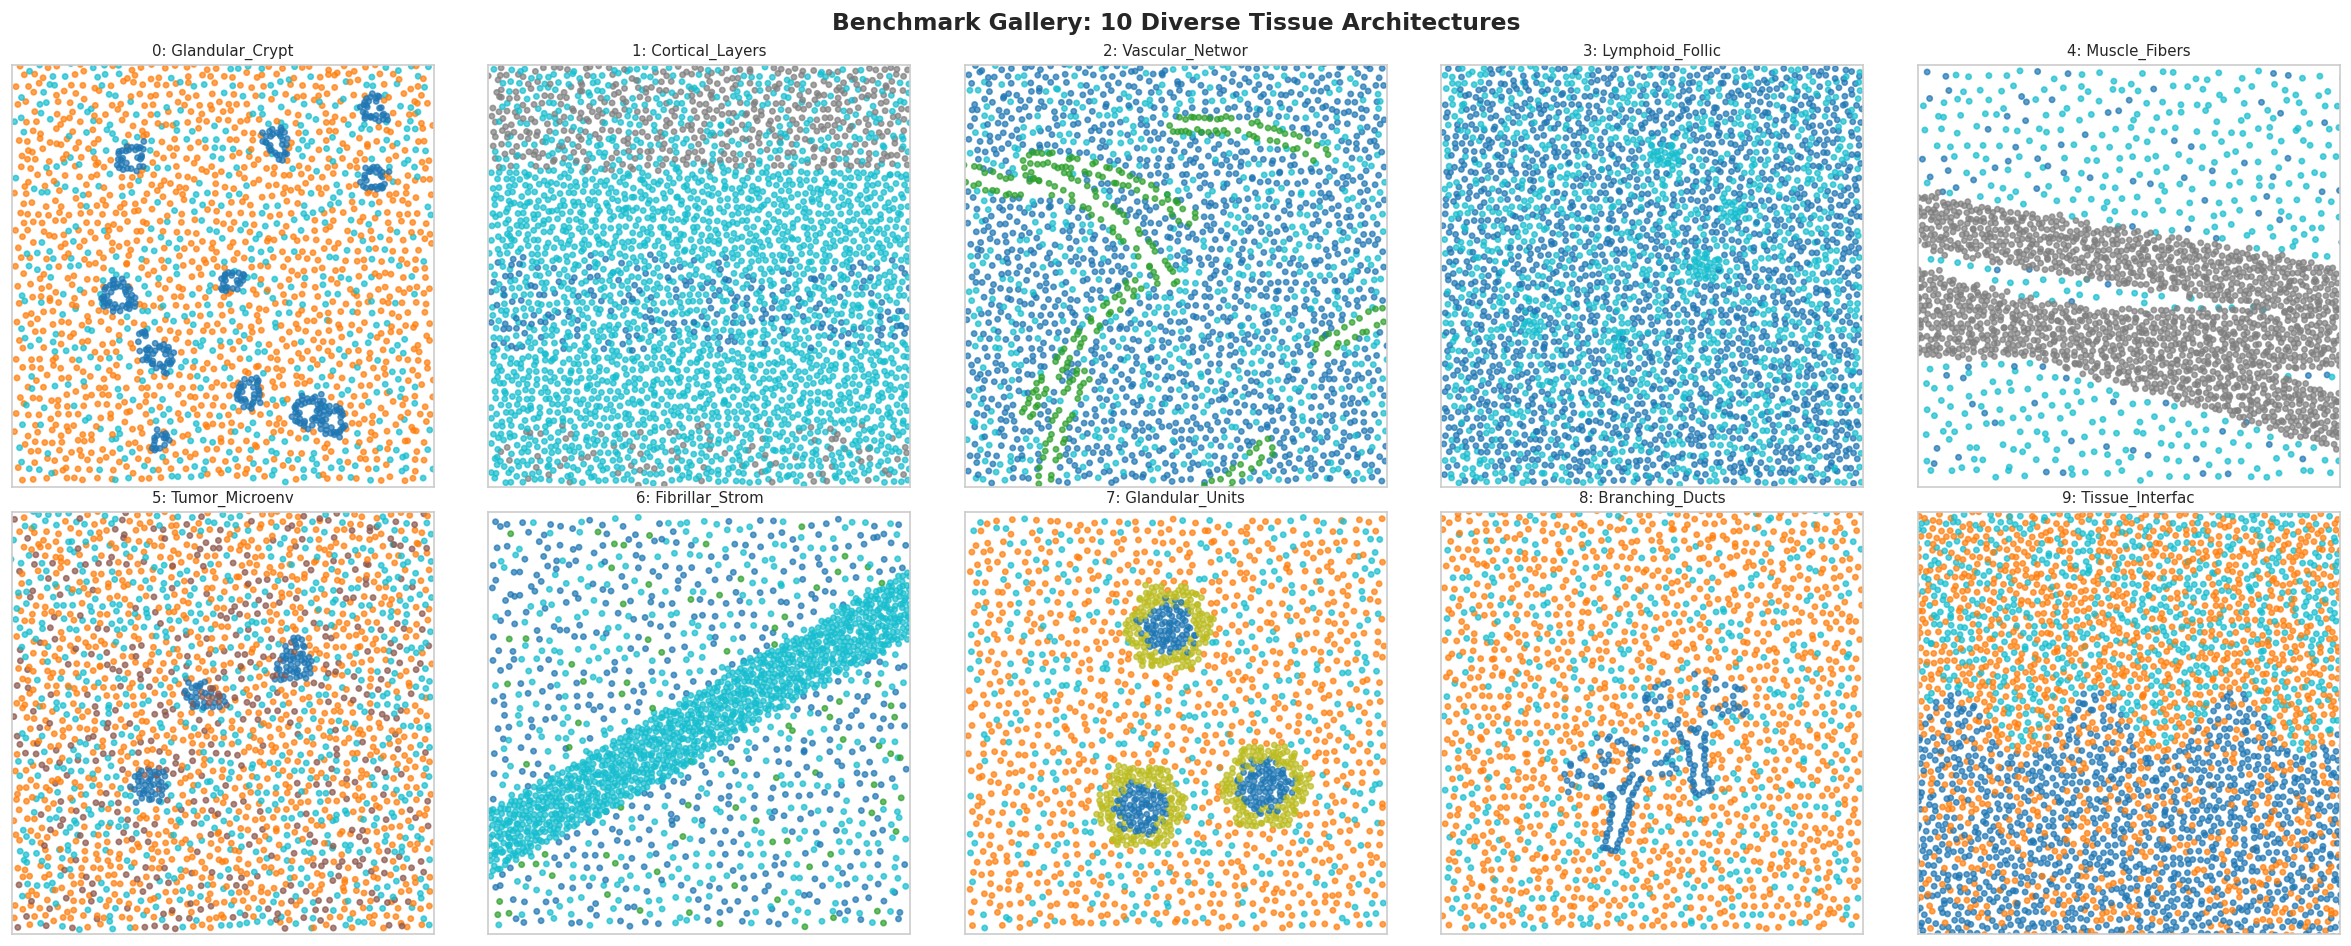

✓ Gallery overview saved


In [7]:
# Create gallery overview
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

frame_size = BENCHMARK_CONFIG['frame_size']

for idx, fov_data in enumerate(benchmark_data):
    ax = axes[idx]
    fov = fov_data['fov']
    
    # Plot cells as scatter
    ax.scatter(
        fov.cell_centroids[:, 0],
        fov.cell_centroids[:, 1],
        c=fov.class_instance,
        cmap='tab10',
        s=10,
        alpha=0.7
    )
    
    ax.set_xlim(0, frame_size)
    ax.set_ylim(0, frame_size)
    ax.set_aspect('equal')
    ax.set_title(f"{fov_data['fov_id']}: {fov_data['name'][:15]}", fontsize=9)
    ax.set_xticks([])
    ax.set_yticks([])

plt.suptitle('Benchmark Gallery: 10 Diverse Tissue Architectures', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('benchmarks/figures/gallery_overview.png', dpi=200, bbox_inches='tight')
plt.show()

print("✓ Gallery overview saved")

## 6. Calculate Difficulty Scores

Quantify the expected difficulty of each FOV for cell type classification.

In [8]:
def calculate_difficulty_metrics(fov_data, tissue):
    """Calculate multiple difficulty metrics for a FOV."""
    fov = fov_data['fov']
    dots_df = fov_data['dots_df']
    cells_df = fov_data['cells_df']
    
    metrics = {}
    
    # 1. Sparsity score (lower = sparser)
    fg_dots = dots_df[dots_df['cell'] >= 0]
    metrics['transcripts_per_cell'] = len(fg_dots) / fov.n_cells if fov.n_cells > 0 else 0
    metrics['sparsity_score'] = 1.0 / (1.0 + metrics['transcripts_per_cell'] / 10.0)
    
    # 2. Cell size variation
    if hasattr(fov, 'cell_major_axis'):
        sizes = fov.cell_major_axis * 2
        metrics['size_cv'] = np.std(sizes) / np.mean(sizes) if np.mean(sizes) > 0 else 0
    else:
        metrics['size_cv'] = 0
    
    # 3. Cell type distinctness (based on expression)
    type_means = tissue.gene_expression_by_type.mean(axis=0)
    from scipy.spatial.distance import pdist
    if len(type_means) > 1:
        pairwise_dists = pdist(tissue.gene_expression_by_type.T)
        metrics['expression_separation'] = np.mean(pairwise_dists)
    else:
        metrics['expression_separation'] = 0
    
    # 4. Spatial mixing (entropy of local neighborhoods)
    from scipy.spatial import KDTree
    if len(fov.cell_centroids) > 10:
        tree = KDTree(fov.cell_centroids)
        k = min(10, len(fov.cell_centroids) - 1)
        _, indices = tree.query(fov.cell_centroids, k=k+1)
        
        local_entropies = []
        for i in range(len(fov.cell_centroids)):
            neighbors = indices[i][1:]  # Exclude self
            neighbor_types = fov.class_instance[neighbors]
            unique, counts = np.unique(neighbor_types, return_counts=True)
            probs = counts / counts.sum()
            entropy = -np.sum(probs * np.log(probs + 1e-10))
            local_entropies.append(entropy)
        metrics['spatial_mixing'] = np.mean(local_entropies)
    else:
        metrics['spatial_mixing'] = 0
    
    # 5. Overall difficulty score (weighted combination)
    metrics['overall_difficulty'] = (
        0.3 * metrics['sparsity_score'] +
        0.2 * min(metrics['size_cv'], 1.0) +
        0.3 * (1.0 - min(metrics['expression_separation'] / 20.0, 1.0)) +
        0.2 * min(metrics['spatial_mixing'] / 2.0, 1.0)
    )
    
    return metrics

# Calculate metrics for all FOVs
print("Calculating difficulty metrics...\n")
print(f"{'FOV':<20s} {'Sparsity':<12s} {'Difficulty':<12s} {'Trans/Cell':<12s} {'Overall':<10s}")
print("=" * 70)

for fov_data in benchmark_data:
    metrics = calculate_difficulty_metrics(fov_data, tissue)
    fov_data['metrics'] = metrics
    
    print(f"{fov_data['name']:<20s} "
          f"{fov_data['sparsity']:<12s} "
          f"{fov_data['difficulty']:<12s} "
          f"{metrics['transcripts_per_cell']:<12.1f} "
          f"{metrics['overall_difficulty']:<10.3f}")

print("\n✓ Difficulty metrics calculated")

Calculating difficulty metrics...

FOV                  Sparsity     Difficulty   Trans/Cell   Overall   
Glandular_Crypts     medium       easy         10.9         0.480     


Cortical_Layers      low          medium       12.1         0.462     
Vascular_Network     high         easy         5.8          0.535     
Lymphoid_Follicles   medium       medium       9.7          0.501     
Muscle_Fibers        low          hard         11.7         0.448     
Tumor_Microenv       very_high    hard         3.4          0.623     
Fibrillar_Stroma     high         medium       6.4          0.508     
Glandular_Units      medium       medium       9.7          0.495     
Branching_Ducts      very_low     easy         15.9         0.455     
Tissue_Interface     high         hard         5.6          0.557     

✓ Difficulty metrics calculated


## 7. Export Benchmark Data

Save all FOVs, ground truth, and metadata for benchmarking.

In [10]:
# Export each FOV
print("Exporting benchmark data...\n")

for fov_data in benchmark_data:
    fov_id = fov_data['fov_id']
    
    # Ground truth: cells with types and positions
    cells_path = f"benchmarks/data/ground_truth_cells_fov{fov_id:02d}.csv"
    fov_data['cells_df'].to_csv(cells_path, index=False)
    
    # Ground truth: dots with cell assignments
    dots_path = f"benchmarks/data/ground_truth_dots_fov{fov_id:02d}.csv"
    fov_data['dots_df'].to_csv(dots_path, index=False)
    
    # Observable data: dots without cell assignments (for methods to predict)
    observable_dots = fov_data['dots_df'][['x', 'y', 'gene']].copy()
    observable_path = f"benchmarks/data/observable_dots_fov{fov_id:02d}.csv"
    observable_dots.to_csv(observable_path, index=False)
    
    # Cell centroids only (for methods that need cell locations)
    # Note: cells_df uses uppercase 'X', 'Y' columns
    centroids_df = fov_data['cells_df'][['X', 'Y']].copy()
    centroids_df.columns = ['x', 'y']  # Rename to lowercase for consistency
    centroids_path = f"benchmarks/data/cell_centroids_fov{fov_id:02d}.csv"
    centroids_df.to_csv(centroids_path, index=False)
    
    print(f"✓ FOV {fov_id:02d} ({fov_data['name']}): 4 files exported")

# Export expression matrix
expr_matrix = pd.DataFrame(
    tissue.gene_expression_by_type,
    index=tissue.gene_names,
    columns=tissue._cell_type_names
)
expr_matrix.to_csv('benchmarks/data/expression_matrix.csv')
print("\n✓ Expression matrix exported")

# Export metadata
metadata = {
    'benchmark_name': 'cell_type_mapping_sparsity',
    'creation_date': datetime.now().isoformat(),
    'n_fovs': len(benchmark_data),
    'frame_size': BENCHMARK_CONFIG['frame_size'],
    'n_cell_types': BENCHMARK_CONFIG['n_cell_types'],
    'n_genes': BENCHMARK_CONFIG['n_genes'],
    'cell_type_names': tissue._cell_type_names,
    'gene_names': tissue.gene_names.tolist(),
    'configuration': BENCHMARK_CONFIG,
    'fovs': [
        {
            'fov_id': fd['fov_id'],
            'name': fd['name'],
            'sparsity': fd['sparsity'],
            'difficulty': fd['difficulty'],
            'n_cells': fd['n_cells'],
            'n_transcripts': fd['n_transcripts'],
            'metrics': fd['metrics'],
        }
        for fd in benchmark_data
    ]
}

with open('benchmarks/data/metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print("✓ Metadata exported")
print("\n✓ All data exported to benchmarks/data/")

Exporting benchmark data...

✓ FOV 00 (Glandular_Crypts): 4 files exported
✓ FOV 01 (Cortical_Layers): 4 files exported
✓ FOV 02 (Vascular_Network): 4 files exported
✓ FOV 03 (Lymphoid_Follicles): 4 files exported
✓ FOV 04 (Muscle_Fibers): 4 files exported
✓ FOV 05 (Tumor_Microenv): 4 files exported
✓ FOV 06 (Fibrillar_Stroma): 4 files exported
✓ FOV 07 (Glandular_Units): 4 files exported
✓ FOV 08 (Branching_Ducts): 4 files exported
✓ FOV 09 (Tissue_Interface): 4 files exported

✓ Expression matrix exported
✓ Metadata exported

✓ All data exported to benchmarks/data/


## 8. Summary and Statistics

Visualize benchmark characteristics and statistics.

Benchmark Summary:
 FOV_ID               Name  Sparsity Difficulty  N_Cells  N_Transcripts  Trans/Cell  Overall_Difficulty  Spatial_Mixing  Size_CV
      0   Glandular_Crypts    medium       easy     2096          23381   10.936546            0.479680        0.563892 0.122857
      1    Cortical_Layers       low     medium     3233          40032   12.139808            0.461599        0.361848 0.172412
      2   Vascular_Network      high       easy     2313          13739    5.823606            0.534930        0.663096 0.118006
      3 Lymphoid_Follicles    medium     medium     3296          32656    9.713592            0.500936        0.611011 0.161132
      4      Muscle_Fibers       low       hard     2261          26995   11.705440            0.448328        0.147997 0.199423
      5     Tumor_Microenv very_high       hard     2338           8166    3.424294            0.622879        0.908219 0.265761
      6   Fibrillar_Stroma      high     medium     2121          13779    6.3

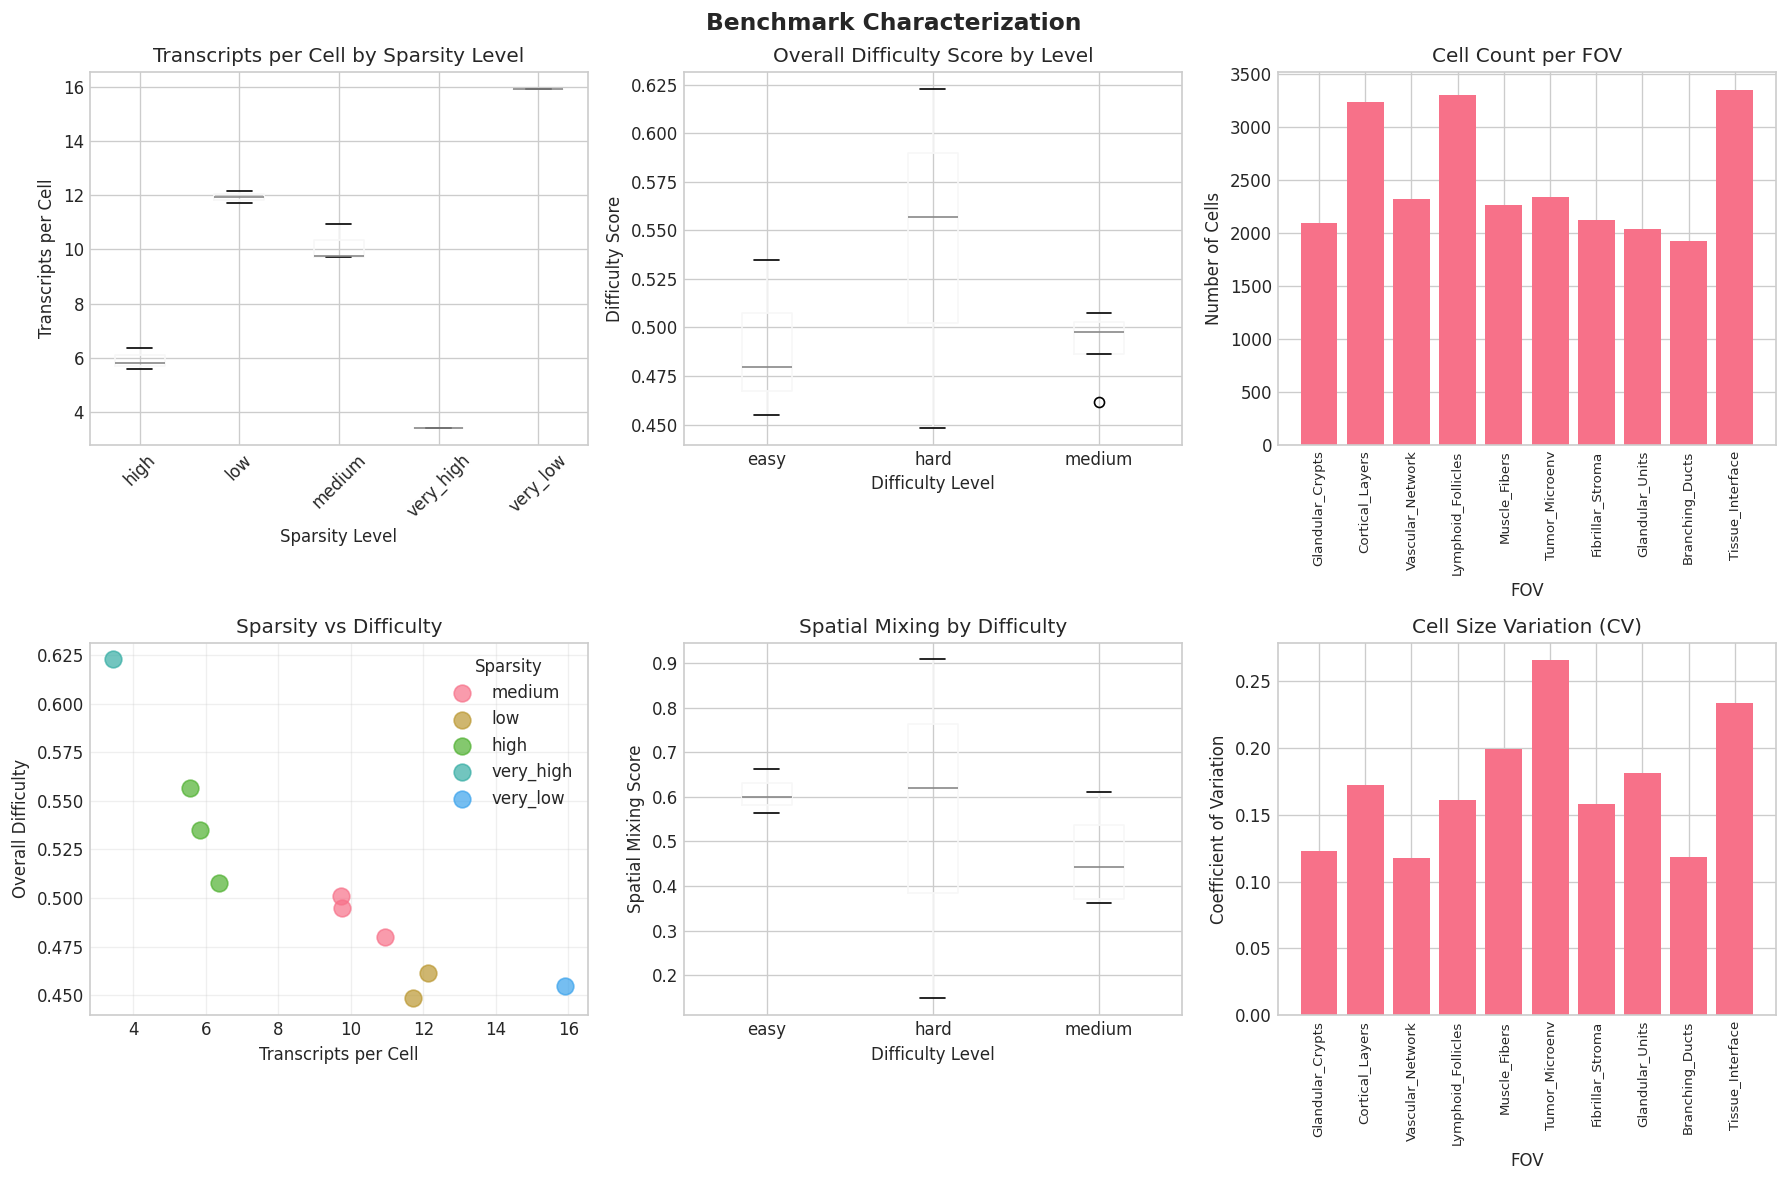


✓ Statistics visualization saved
✓ Summary table exported to benchmarks/results/benchmark_summary.csv


In [11]:
# Create summary dataframe
summary_df = pd.DataFrame([
    {
        'FOV_ID': fd['fov_id'],
        'Name': fd['name'],
        'Sparsity': fd['sparsity'],
        'Difficulty': fd['difficulty'],
        'N_Cells': fd['n_cells'],
        'N_Transcripts': fd['n_transcripts'],
        'Trans/Cell': fd['metrics']['transcripts_per_cell'],
        'Overall_Difficulty': fd['metrics']['overall_difficulty'],
        'Spatial_Mixing': fd['metrics']['spatial_mixing'],
        'Size_CV': fd['metrics']['size_cv'],
    }
    for fd in benchmark_data
])

print("Benchmark Summary:")
print("=" * 100)
print(summary_df.to_string(index=False))
print("=" * 100)

# Summary statistics
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# 1. Transcripts per cell by sparsity
ax = axes[0, 0]
summary_df.boxplot(column='Trans/Cell', by='Sparsity', ax=ax)
ax.set_title('Transcripts per Cell by Sparsity Level')
ax.set_xlabel('Sparsity Level')
ax.set_ylabel('Transcripts per Cell')
plt.sca(ax)
plt.xticks(rotation=45)

# 2. Overall difficulty distribution
ax = axes[0, 1]
summary_df.boxplot(column='Overall_Difficulty', by='Difficulty', ax=ax)
ax.set_title('Overall Difficulty Score by Level')
ax.set_xlabel('Difficulty Level')
ax.set_ylabel('Difficulty Score')

# 3. Cell count distribution
ax = axes[0, 2]
ax.bar(summary_df['Name'], summary_df['N_Cells'])
ax.set_title('Cell Count per FOV')
ax.set_xlabel('FOV')
ax.set_ylabel('Number of Cells')
plt.sca(ax)
plt.xticks(rotation=90, fontsize=8)

# 4. Sparsity vs Difficulty scatter
ax = axes[1, 0]
for sparsity in summary_df['Sparsity'].unique():
    data = summary_df[summary_df['Sparsity'] == sparsity]
    ax.scatter(data['Trans/Cell'], data['Overall_Difficulty'], label=sparsity, s=100, alpha=0.7)
ax.set_xlabel('Transcripts per Cell')
ax.set_ylabel('Overall Difficulty')
ax.set_title('Sparsity vs Difficulty')
ax.legend(title='Sparsity')
ax.grid(True, alpha=0.3)

# 5. Spatial mixing by difficulty
ax = axes[1, 1]
summary_df.boxplot(column='Spatial_Mixing', by='Difficulty', ax=ax)
ax.set_title('Spatial Mixing by Difficulty')
ax.set_xlabel('Difficulty Level')
ax.set_ylabel('Spatial Mixing Score')

# 6. Cell size variation
ax = axes[1, 2]
ax.bar(summary_df['Name'], summary_df['Size_CV'])
ax.set_title('Cell Size Variation (CV)')
ax.set_xlabel('FOV')
ax.set_ylabel('Coefficient of Variation')
plt.sca(ax)
plt.xticks(rotation=90, fontsize=8)

plt.suptitle('Benchmark Characterization', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('benchmarks/figures/benchmark_statistics.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Statistics visualization saved")

# Export summary
summary_df.to_csv('benchmarks/results/benchmark_summary.csv', index=False)
print("✓ Summary table exported to benchmarks/results/benchmark_summary.csv")

## 9. Using This Benchmark

### Data Structure

The benchmark generates the following files in `benchmarks/data/`:

**Per FOV (10 files each):**
- `ground_truth_cells_fov##.csv` - Cell positions, types, and morphology
- `ground_truth_dots_fov##.csv` - Transcript positions with cell assignments
- `observable_dots_fov##.csv` - Transcript positions and genes (for methods to predict)
- `cell_centroids_fov##.csv` - Cell centroid positions only

**Shared:**
- `expression_matrix.csv` - Gene expression profiles per cell type
- `metadata.json` - Complete benchmark configuration and metrics

### Evaluation Protocol

1. **Input**: Use `observable_dots_fov##.csv` + `cell_centroids_fov##.csv` + `expression_matrix.csv`
2. **Task**: Assign each transcript to a cell and predict cell type for each cell
3. **Ground Truth**: Compare against `ground_truth_dots_fov##.csv` and `ground_truth_cells_fov##.csv`

### Evaluation Metrics

**Cell Type Assignment:**
- Accuracy: Fraction of correctly assigned cell types
- F1 score: Per cell type and macro-averaged
- Confusion matrix: Predicted vs true types

**Transcript Assignment:**
- Assignment accuracy: Fraction of correctly assigned transcripts
- Per-cell purity: Fraction of each cell's transcripts correctly assigned

**Stratified Analysis:**
- Performance by sparsity level (very_low, low, medium, high, very_high)
- Performance by difficulty level (easy, medium, hard)
- Performance by tissue architecture type

### Example Evaluation Code

```python
# Load ground truth
ground_truth = pd.read_csv('benchmarks/data/ground_truth_cells_fov00.csv')
dots_truth = pd.read_csv('benchmarks/data/ground_truth_dots_fov00.csv')

# Your method predictions
predicted_types = your_method(observable_dots, cell_centroids, expression_matrix)

# Evaluate
from sklearn.metrics import accuracy_score, f1_score
accuracy = accuracy_score(ground_truth['cell_type'], predicted_types)
f1 = f1_score(ground_truth['cell_type'], predicted_types, average='macro')
```

### Benchmark Goals

This benchmark allows you to:
1. Evaluate how methods perform across different sparsity levels
2. Test robustness to varying difficulty (cell type similarity, spatial mixing)
3. Compare performance on diverse tissue architectures
4. Identify method strengths and weaknesses in specific scenarios

---

## Benchmark Complete!

All data has been generated and saved. You can now:
- Use the exported data to test cell type mapping methods
- Analyze method performance across different conditions
- Generate additional FOVs with modified parameters
- Visualize results and create comparison plots